Mounted at /content/drive
Cargando datos y modelos...
Realizando train_test_split...

=============== REPORTE TEST: Regresión Logística ===============
              precision    recall  f1-score   support

           0       0.84      0.72      0.77    160000
           2       0.00      0.00      0.00         0
           4       0.84      0.73      0.78    160000

    accuracy                           0.72    320000
   macro avg       0.56      0.48      0.52    320000
weighted avg       0.84      0.72      0.77    320000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


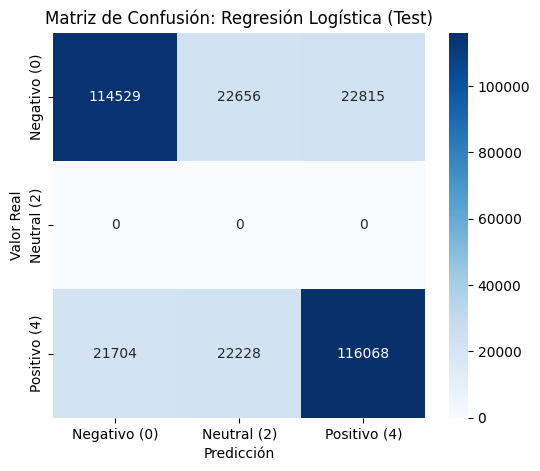


=============== REPORTE TEST: Naive Bayes ===============


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.84      0.68      0.75    160000
           2       0.00      0.00      0.00         0
           4       0.86      0.61      0.71    160000

    accuracy                           0.64    320000
   macro avg       0.57      0.43      0.49    320000
weighted avg       0.85      0.64      0.73    320000



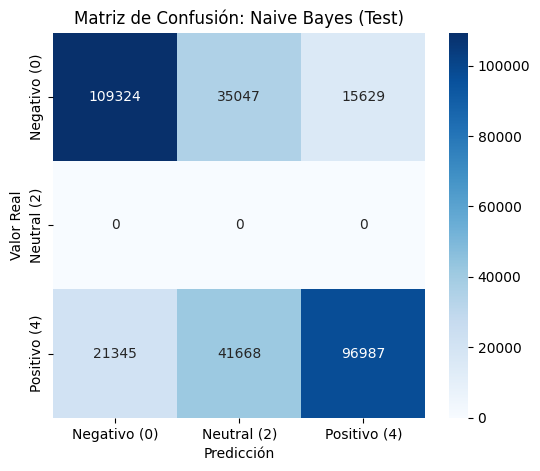

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')

# 1. Rutas (ajusta si es necesario)
export_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Models/'
data_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/train_topicos.csv'

# 2. Cargar el dataset original y los modelos exportados
print("Cargando datos y modelos...")
df = pd.read_csv(data_path)
df['text_avanzado'] = df['text_avanzado'].fillna('')

tfidf = joblib.load(export_path + 'tfidf_vectorizer.joblib')
lr_model = joblib.load(export_path + 'lr_model.joblib')
nb_model = joblib.load(export_path + 'nb_model.joblib')

# 3. Recrear el Split exacto (asegurando el mismo random_state para mantener la consistencia)
print("Realizando train_test_split...")
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# Vectorizar únicamente el set de test con el tfidf ya entrenado
X_test_vec = tfidf.transform(df_test['text_avanzado'])

# 4. Función de umbral para la clase neutral (2)
def get_predictions_with_threshold(model, X_data, threshold=0.6):
    probs = model.predict_proba(X_data)
    max_probs = probs.max(axis=1)
    predictions = model.predict(X_data)
    return np.where(max_probs < threshold, 2, predictions)

# Función para graficar la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo (0)', 'Neutral (2)', 'Positivo (4)'],
                yticklabels=['Negativo (0)', 'Neutral (2)', 'Positivo (4)'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title(title)
    plt.show()

# 5. Validación y Evaluación en el Test Set para ambos modelos
threshold = 0.6
models = {'Regresión Logística': lr_model, 'Naive Bayes': nb_model}

for name, model in models.items():
    print(f"\n{'='*15} REPORTE TEST: {name} {'='*15}")

    # Obtener predicciones con umbral
    preds_test = get_predictions_with_threshold(model, X_test_vec, threshold)

    # Imprimir reporte
    print(classification_report(df_test['target'], preds_test))

    # Generar matriz de confusión
    plot_confusion_matrix(df_test['target'], preds_test, f'Matriz de Confusión: {name} (Test)')

Al aplicar el threshold, ambos modelos predicen el tercer outcome, los tweet neutros, por incertidumbre en la predicción.
Aunque el Naive Bayes envió mas predicciones positivas y negativas a la categoria neutra debido a que el modelo hace predicciones
por probabilidad mas extremas en modelo de bolsas de palabras.

Calculando predicciones con TextBlob...

=============== REPORTE TEST: TextBlob (Baseline) ===============
              precision    recall  f1-score   support

           0       0.77      0.25      0.38    160000
           2       0.00      0.00      0.00         0
           4       0.66      0.50      0.57    160000

    accuracy                           0.38    320000
   macro avg       0.48      0.25      0.32    320000
weighted avg       0.71      0.38      0.47    320000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


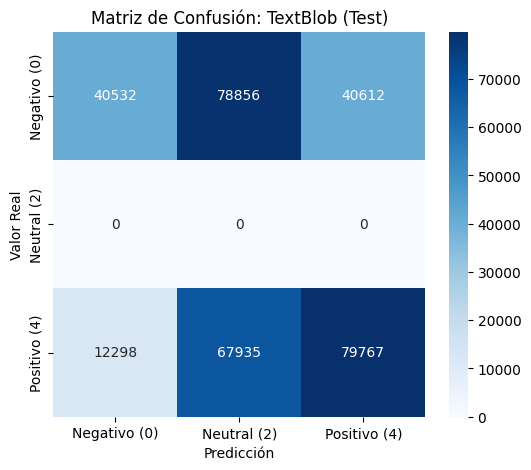

In [4]:
from textblob import TextBlob

# 1. Función para mapear la polaridad de TextBlob a tus etiquetas (0, 2, 4)
def classify_sentiment_textblob(text):
    analysis = TextBlob(text)
    # Definimos umbrales estándar de polaridad:
    # < -0.1 : Negativo (0)
    # >  0.1 : Positivo (4)
    # Entre -0.1 y 0.1 : Neutral (2)
    if analysis.sentiment.polarity < -0.1:
        return 0
    elif analysis.sentiment.polarity > 0.1:
        return 4
    else:
        return 2

# 2. Aplicar TextBlob al conjunto de test (df_test)
print("Calculando predicciones con TextBlob...")
df_test['textblob_pred'] = df_test['text_avanzado'].apply(classify_sentiment_textblob)

# 3. Reporte de clasificación para TextBlob
print(f"\n{'='*15} REPORTE TEST: TextBlob (Baseline) {'='*15}")
print(classification_report(df_test['target'], df_test['textblob_pred']))

# 4. Matriz de confusión para TextBlob (usando la función que ya definiste antes)
plot_confusion_matrix(df_test['target'], df_test['textblob_pred'], 'Matriz de Confusión: TextBlob (Test)')

Como conclución final, se encuentra que el textblob obtuvo un accuracy muy inferior los mmodelos entrenados, lo cual se asume que es debido a la propia naturaleza del modelo al ser pre-entrenado con un diccionario y reglas ya cargados.
Mientras que la reglesión logistica y naive bayes logras resultados similares, pero al aplicar el threshold actua de forma diferente en debido al funcionamiento de cada uno, siendo definitivamente mas certero el modelo de regresión logistica.